In [1]:
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import rasterio

class EuroSATMultispectral(Dataset):
    def __init__(self, csv_path, root_dir):
        self.df = pd.read_csv(csv_path)
        self.root_dir = root_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        rel_path = row['filename'].replace('\\', os.sep).replace('.jpg', '.tif')
        full_path = os.path.join(self.root_dir, rel_path)

        with rasterio.open(full_path) as src:
            img = src.read().astype(np.float32) / 5000.0

        return torch.tensor(img), int(row['label'])

In [2]:
import torch
import torch.nn as nn
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

train_ds = EuroSATMultispectral(
    r"C:\Users\Kavya\GeoSnap\train.csv", 
    r"C:\Users\Kavya\GeoSnap\EuroSATallBands\train"
)
val_ds = EuroSATMultispectral(
    r"C:\Users\Kavya\GeoSnap\validation.csv", 
    r"C:\Users\Kavya\GeoSnap\EuroSATallBands\val"
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)

cpu


In [3]:
import timm
import torch
import torch.nn as nn

model = timm.create_model(
    "resnet18",
    pretrained=False,
    num_classes=10
)

old_conv = model.conv1

new_conv = nn.Conv2d(
    13, 64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

with torch.no_grad():
    new_conv.weight = nn.Parameter(
        old_conv.weight.mean(dim=1, keepdim=True).repeat(1,13,1,1)
    )

model.conv1 = new_conv

In [4]:
model.load_state_dict(
    torch.load("best_model.pth", map_location=device)
)

model.to(device)
model.eval()

print("loaded successfully")

loaded successfully


In [5]:
print(model)
# structure of the CNN

ResNet(
  (conv1): Conv2d(13, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act1): ReLU(inplace=True)
      (aa): Identity()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, 

In [6]:
class_names = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake"
]

(10, 13)


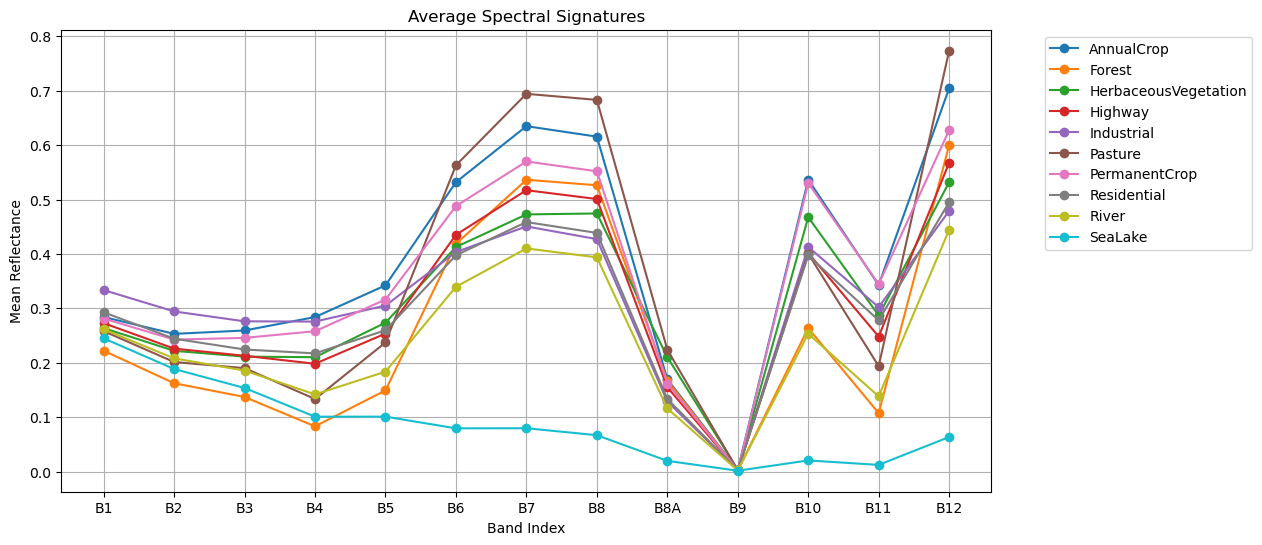

In [7]:
import numpy as np
import matplotlib.pyplot as plt

num_classes = len(class_names)
num_bands = 13

mean_signatures = np.zeros((num_classes, num_bands))
counts = np.zeros(num_classes)

for i in range(len(val_ds)):

    img, label = val_ds[i]

    img = img.numpy()  # (13,64,64)

    # mean reflectance of each band for this image
    band_means = img.mean(axis=(1,2))

    mean_signatures[label] += band_means
    counts[label] += 1

# average across all images in class
for c in range(num_classes):
    mean_signatures[c] /= counts[c]

print(mean_signatures.shape)

plt.figure(figsize=(12,6))

for c in range(num_classes):
    plt.plot(
        range(13),
        mean_signatures[c],
        marker='o',
        label=class_names[c]
    )

band_names = [
    "B1","B2","B3","B4","B5","B6","B7",
    "B8","B8A","B9","B10","B11","B12"
]

plt.xlabel("Band Index")
plt.ylabel("Mean Reflectance")
plt.xticks(range(13), band_names)
plt.title("Average Spectral Signatures")
plt.legend(bbox_to_anchor=(1.05,1))
plt.grid(True)

plt.savefig(
    "average_spectral_signatures.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# The class-wise mean spectral signatures were visualized to compare reflectance patterns across the Sentinel-2 spectrum. Differences in the shape and magnitude of these curves help explain class separability, confusion patterns, and the spectral information exploited by the CNN during classification.

In [8]:
import torch.nn as nn

feature_extractor = nn.Sequential(
    *list(model.children())[:-1]
)

feature_extractor.eval()
# removes the final classifier layer and converts the trained ResNet into a pure feature extractor that outputs the 512-dimensional embedding learned by the network, which can then be analyzed using techniques such as t-SNE.

Sequential(
  (0): Conv2d(13, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act1): ReLU(inplace=True)
      (aa): Identity()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, af

In [9]:
import numpy as np
import torch

all_features = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:

        imgs = imgs.to(device)

        features = feature_extractor(imgs)

        # shape: (batch, 512, 1, 1)
        features = features.squeeze(-1).squeeze(-1)

        all_features.append(features.cpu().numpy())
        all_labels.append(labels.numpy())

all_features = np.vstack(all_features)
all_labels = np.concatenate(all_labels)

print(all_features.shape)
print(all_labels.shape)

# To visualize the learned feature space, the final classification layer was removed and the trained ResNet-18 was used as a feature extractor. Each validation image was passed through the network to obtain a 512-dimensional feature embedding representing the model's internal representation prior to classification.

(4050, 512)
(4050,)


In [10]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

emb_2d = tsne.fit_transform(all_features)

print(emb_2d.shape)
# t-SNE was applied to the 512-dimensional feature embeddings to generate a two-dimensional visualization of the learned feature space. This enables qualitative assessment of class separability, cluster formation, and inter-class overlap within the network's internal representations

(4050, 2)


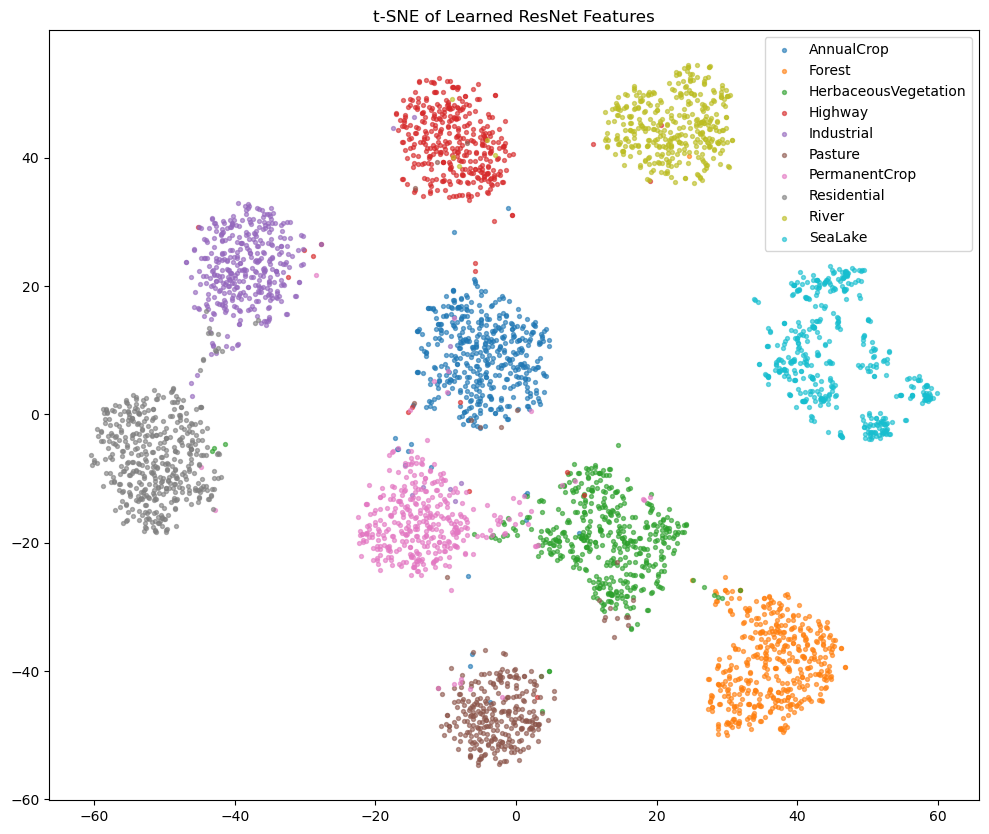

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

for i, cls in enumerate(class_names):
    idx = all_labels == i

    plt.scatter(
        emb_2d[idx,0],
        emb_2d[idx,1],
        s=8,
        alpha=0.6,
        label=cls
    )

plt.legend()
plt.title("t-SNE of Learned ResNet Features")
plt.savefig(
    "tsne_features_highres.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()
# Each point represents a validation image, positioned according to its learned 512-dimensional feature representation and colored by its ground-truth class label.

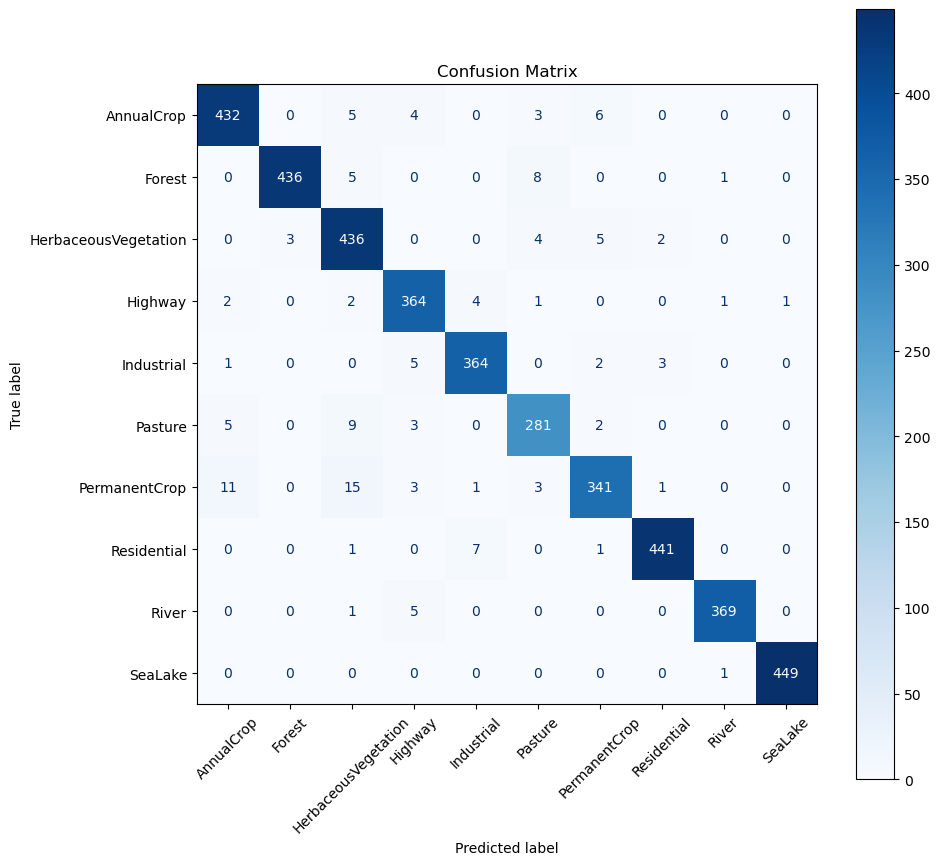

                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.96      0.96       450
              Forest       0.99      0.97      0.98       450
HerbaceousVegetation       0.92      0.97      0.94       450
             Highway       0.95      0.97      0.96       375
          Industrial       0.97      0.97      0.97       375
             Pasture       0.94      0.94      0.94       300
       PermanentCrop       0.96      0.91      0.93       375
         Residential       0.99      0.98      0.98       450
               River       0.99      0.98      0.99       375
             SeaLake       1.00      1.00      1.00       450

            accuracy                           0.97      4050
           macro avg       0.97      0.96      0.96      4050
        weighted avg       0.97      0.97      0.97      4050



In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt
import torch

y_true = []
y_pred = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))
# Displaying confusion matrix 

In [13]:
import torch

def evaluate_accuracy(loader, zero_band_idx=None):
    correct, total = 0, 0
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.clone()
            if zero_band_idx is not None:
                imgs[:, zero_band_idx, :, :] = 0
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

# baseline first
baseline_acc = evaluate_accuracy(val_loader)
print(f"Baseline accuracy: {baseline_acc:.4f}")

# now zero out each band one at a time
band_names = ["B1","B2","B3","B4","B5","B6","B7","B8","B8A","B9","B10","B11","B12"]
drops = []

for band_idx in range(13):
    acc = evaluate_accuracy(val_loader, zero_band_idx=band_idx)
    drop = baseline_acc - acc
    drops.append(drop)
    print(f"Band {band_idx + 1} ({band_names[band_idx]}): acc={acc:.4f}  drop={drop:.4f}")

# Band importance was estimated through a leave-one-band-out ablation strategy. Starting from the baseline validation accuracy, each spectral band was independently zeroed while keeping all other bands unchanged. The reduction in classification accuracy relative to the baseline was used as a measure of the importance of that band within the learned classification model.

Baseline accuracy: 0.9662
Band 1 (B1): acc=0.8852  drop=0.0810
Band 2 (B2): acc=0.7519  drop=0.2143
Band 3 (B3): acc=0.7541  drop=0.2121
Band 4 (B4): acc=0.7225  drop=0.2437
Band 5 (B5): acc=0.9259  drop=0.0402
Band 6 (B6): acc=0.8089  drop=0.1573
Band 7 (B7): acc=0.7583  drop=0.2079
Band 8 (B8): acc=0.7701  drop=0.1960
Band 9 (B8A): acc=0.8869  drop=0.0793
Band 10 (B9): acc=0.9662  drop=0.0000
Band 11 (B10): acc=0.6795  drop=0.2867
Band 12 (B11): acc=0.7637  drop=0.2025
Band 13 (B12): acc=0.9207  drop=0.0454


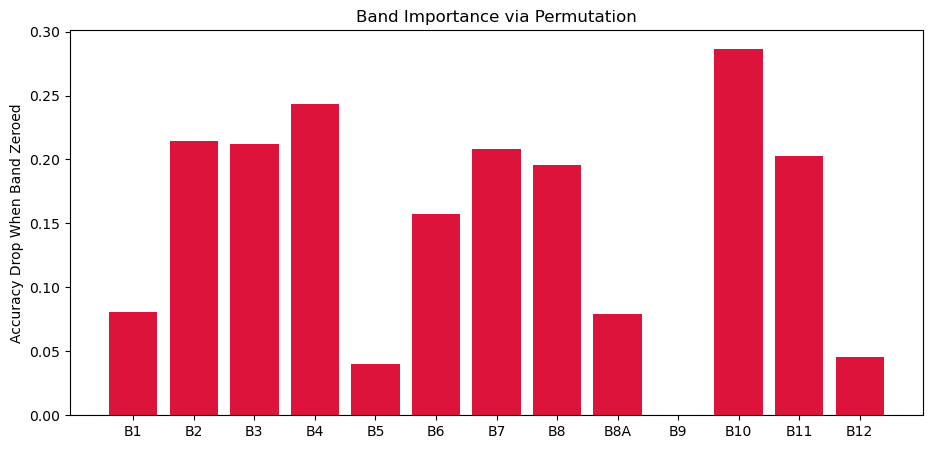

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11,5))
colors = ['crimson' if d > 0.01 else 'steelblue' for d in drops]
plt.bar(band_names, drops, color=colors)
plt.ylabel("Accuracy Drop When Band Zeroed")
plt.title("Band Importance via Permutation")
plt.axhline(0, color='gray', linewidth=0.8)
plt.xticks(rotation=0)
plt.savefig("band_importance.png", dpi=300, bbox_inches="tight")
plt.show()

# The analysis revealed that visible, red-edge, NIR, and SWIR bands contributed most strongly to classification performance, while atmospheric bands such as B9 had minimal impact. This highlights the importance of vegetation, moisture, and surface composition information in distinguishing land-cover classes.

In [15]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

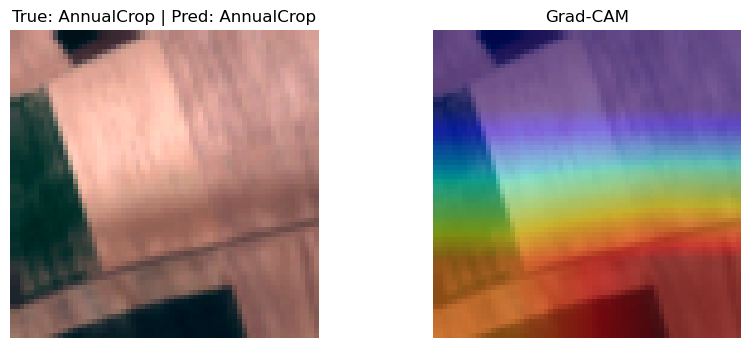

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# pick one validation image
img_tensor, true_label = val_ds[0]   # shape (13, 64, 64)
input_tensor = img_tensor.unsqueeze(0).to(device)  # (1, 13, 64, 64)

# get model's prediction
output = model(input_tensor)
pred_label = output.argmax(1).item()

# generate the heatmap for the predicted class
targets = [ClassifierOutputTarget(pred_label)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]  # (64, 64)

# # build a viewable RGB-like image from bands (using B4,B3,B2 = Red,Green,Blue)
# rgb_img = img_tensor[[3,2,1]].permute(1,2,0).numpy()
# rgb_img = np.clip(rgb_img * 3, 0, 1)  # brighten for visibility

rgb_img = img_tensor[[3,2,1]].permute(1,2,0).numpy()
# rgb_img = np.clip(rgb_img, 0, 1)

p2, p98 = np.percentile(rgb_img, (2, 98))
rgb_img = np.clip((rgb_img - p2) / (p98 - p2), 0, 1)

# overlay
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.title(f"True: {class_names[true_label]} | Pred: {class_names[pred_label]}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(rgb_img)
plt.imshow(grayscale_cam, cmap='jet', alpha=0.5)
plt.title("Grad-CAM")
plt.axis('off')
plt.savefig("gradcam_annualcrop.png",dpi=300,bbox_inches="tight")
plt.show()

In [17]:
permanent_idx = class_names.index('PermanentCrop')
herb_idx = class_names.index('HerbaceousVegetation')

misclassified_pc = []
model.eval()
with torch.no_grad():
    for i in range(len(val_ds)):
        img, label = val_ds[i]
        if label != permanent_idx:
            continue
        out = model(img.unsqueeze(0).to(device))
        pred = out.argmax(1).item()
        if pred == herb_idx:
            misclassified_pc.append(i)

print(f"Found {len(misclassified_pc)} PermanentCrop->HerbaceousVegetation errors")
print(misclassified_pc[:5])

Found 15 PermanentCrop->HerbaceousVegetation errors
[2415, 2421, 2435, 2464, 2468]


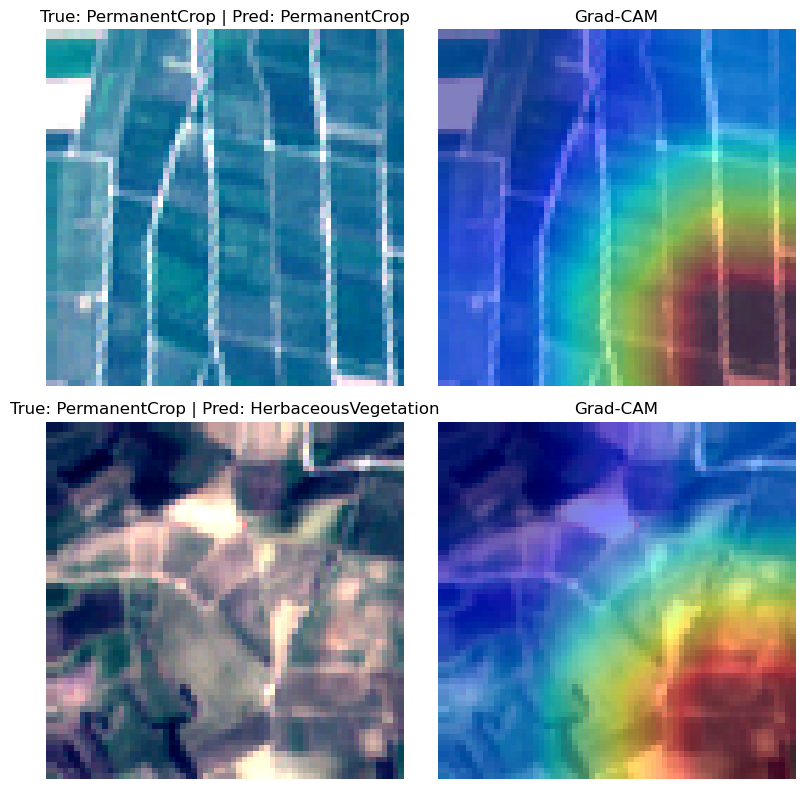

In [18]:
def show_gradcam(idx, ax_pair):
    img_tensor, true_label = val_ds[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)

    output = model(input_tensor)
    pred_label = output.argmax(1).item()

    targets = [ClassifierOutputTarget(pred_label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    rgb_img = img_tensor[[3,2,1]].permute(1,2,0).numpy()
    p2, p98 = np.percentile(rgb_img, (2, 98))
    rgb_img = np.clip((rgb_img - p2) / (p98 - p2 + 1e-6), 0, 1)

    ax_pair[0].imshow(rgb_img)
    ax_pair[0].set_title(f"True: {class_names[true_label]} | Pred: {class_names[pred_label]}")
    ax_pair[0].axis('off')

    ax_pair[1].imshow(rgb_img)
    ax_pair[1].imshow(grayscale_cam, cmap='jet', alpha=0.5)
    ax_pair[1].set_title("Grad-CAM")
    ax_pair[1].axis('off')

# pick one correct PermanentCrop prediction and one misclassified one
correct_pc = [i for i in range(len(val_ds)) if val_ds.df.iloc[i]['label']==permanent_idx][0]
wrong_pc = misclassified_pc[0]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
show_gradcam(correct_pc, axes[0])
show_gradcam(wrong_pc, axes[1])
plt.tight_layout()
plt.savefig("gradcam_permanentcrop_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

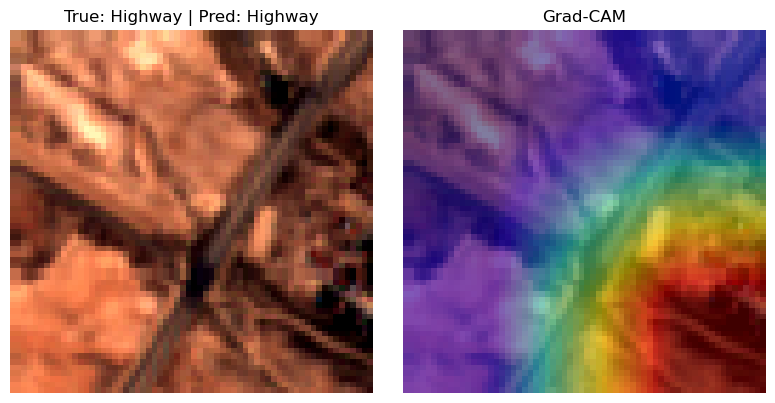

In [19]:
highway_idx = class_names.index('Highway')
correct_hw = [i for i in range(len(val_ds)) if val_ds.df.iloc[i]['label']==highway_idx][2]  # pick any correct one

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
show_gradcam(correct_hw, axes)
plt.tight_layout()
plt.savefig("gradcam_highway.png", dpi=300, bbox_inches="tight")
plt.show()

Found 9 Pasture→HerbaceousVegetation errors


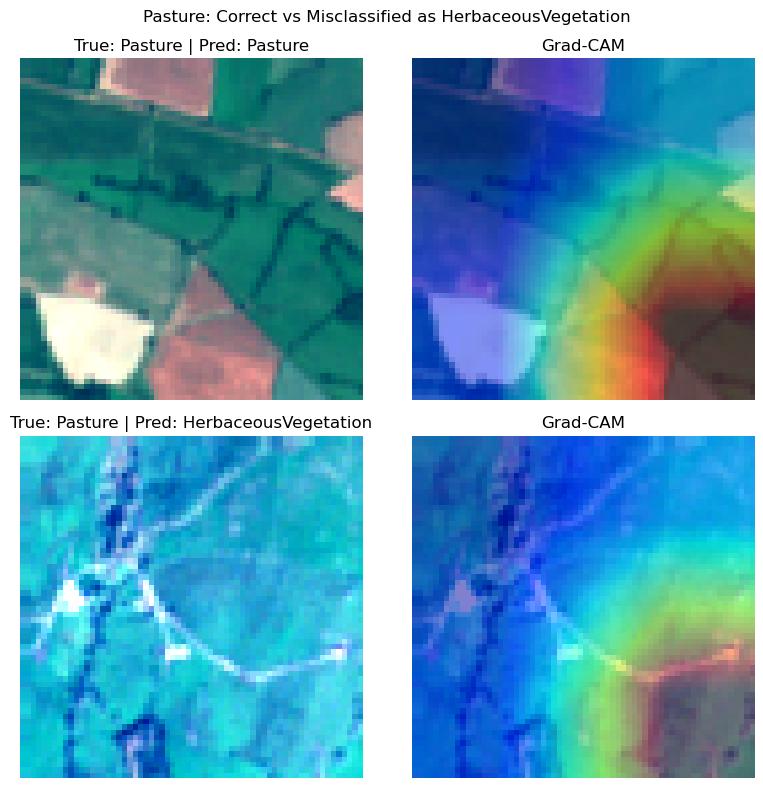

In [20]:
pasture_idx = class_names.index('Pasture')
herb_idx = class_names.index('HerbaceousVegetation')

# find a correct Pasture prediction
correct_pasture = [i for i in range(len(val_ds)) 
                   if val_ds.df.iloc[i]['label'] == pasture_idx][0]

# find a Pasture misclassified as HerbaceousVegetation
wrong_pasture = []
model.eval()
with torch.no_grad():
    for i in range(len(val_ds)):
        if val_ds.df.iloc[i]['label'] != pasture_idx:
            continue
        out = model(val_ds[i][0].unsqueeze(0).to(device))
        if out.argmax(1).item() == herb_idx:
            wrong_pasture.append(i)

print(f"Found {len(wrong_pasture)} Pasture→HerbaceousVegetation errors")

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
fig.suptitle("Pasture: Correct vs Misclassified as HerbaceousVegetation", fontsize=12)
show_gradcam(correct_pasture, axes[0])
show_gradcam(wrong_pasture[0], axes[1])
plt.tight_layout()
plt.savefig("gradcam_pasture_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


Found 7 Residential→Industrial errors


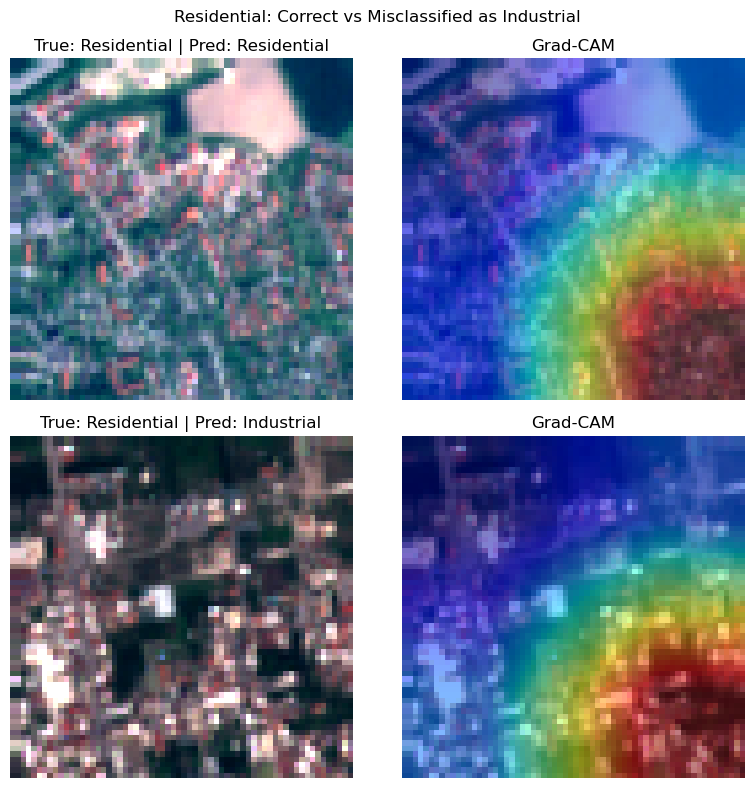

In [21]:
residential_idx = class_names.index('Residential')
industrial_idx = class_names.index('Industrial')

# find a correct Residential prediction
correct_residential = [i for i in range(len(val_ds)) 
                       if val_ds.df.iloc[i]['label'] == residential_idx][0]

# find a Residential misclassified as Industrial
wrong_residential = []
with torch.no_grad():
    for i in range(len(val_ds)):
        if val_ds.df.iloc[i]['label'] != residential_idx:
            continue
        out = model(val_ds[i][0].unsqueeze(0).to(device))
        if out.argmax(1).item() == industrial_idx:
            wrong_residential.append(i)

print(f"Found {len(wrong_residential)} Residential→Industrial errors")

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
fig.suptitle("Residential: Correct vs Misclassified as Industrial", fontsize=12)
show_gradcam(correct_residential, axes[0])
show_gradcam(wrong_residential[0], axes[1])
plt.tight_layout()
plt.savefig("gradcam_residential_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Pasture vs HerbaceousVegetation: The correctly classified Pasture patch exhibits a visible patchwork of field plots separated by distinct boundary lines, reflecting the heterogeneous land management characteristic of pastoral areas. The model's attention concentrates specifically at plot boundaries and regions of high inter-parcel contrast. The misclassified example, by contrast, presents an almost entirely homogeneous surface with no visible structural segmentation, causing attention to disperse uniformly across the patch. Without the plot-boundary cue, the patch is spectrally and spatially indistinguishable from continuous natural vegetation, producing a HerbaceousVegetation prediction. This demonstrates that the model relies partly on structural heterogeneity — not spectral content alone — to identify Pasture, and fails when that cue is absent.


# Residential vs Industrial: The correctly classified Residential patch shows a visibly mixed texture of rooftops, roads, and scattered vegetation, and the model's attention concentrates over the region of highest surface variety. The misclassified example is dominated by large, uniform bright surfaces consistent with expansive industrial roofing or paved areas, with minimal visible vegetation mixing. The model's attention in this case settles on these large homogeneous bright surfaces, which spectrally resemble impervious industrial cover more than the mixed residential signature. This reflects a genuine spectral ambiguity: Residential areas with a high proportion of large rooftops share SWIR-bright, low-NDVI characteristics with Industrial zones, and without sufficient mixed-texture signal to indicate the residential pattern, the model defaults to the built-up class with the most similar dominant spectral response.